In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
np.random.seed(42)
x = np.random.rand(100, 1) - 0.5
y = 3 * x[:, 0] ** 2 + 0.05 * np.random.randn(100)


In [4]:
df = pd.DataFrame()
df['x'] = x.reshape(100)
df['y'] = y

In [5]:
df

,x,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0.5, 1.0, 'Scatter Plot of x vs y')

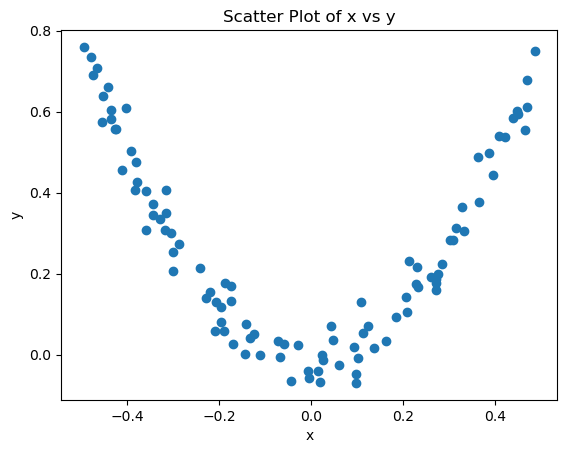

In [6]:
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of x vs y')

In [7]:
#first model.
df['pred1'] = df['y'].mean()

In [8]:
df.head()

,x,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


In [9]:
# residuals error of first model.
df['residuals1'] = df['y'] - df['pred1']

Text(0.5, 0, 'x')

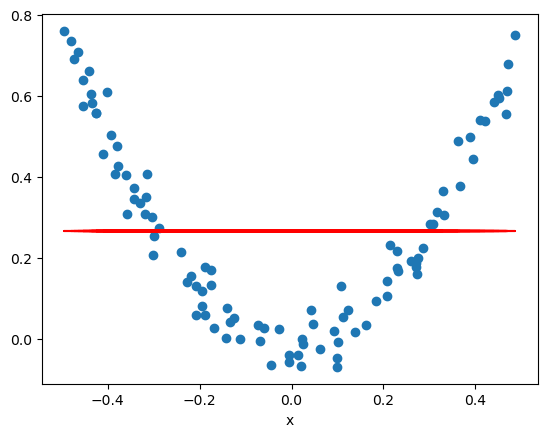

In [10]:
#frist model output.
plt.scatter(df['x'],df['y'])
plt.plot(df['x'], df['pred1'], color='red')
plt.xlabel('x') 

In [11]:
from sklearn.tree import DecisionTreeRegressor
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

In [12]:
tree1.fit(df['x'].values.reshape(100,1),df['residuals1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

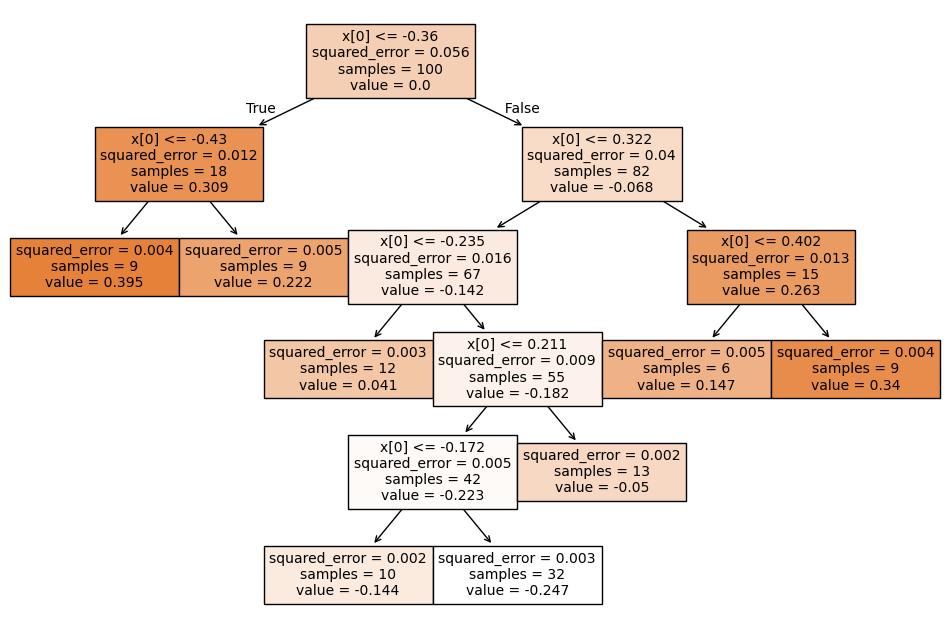

In [13]:
from sklearn.tree import  plot_tree
plt.figure(figsize=(12,8))
plot_tree(tree1, filled=True)
plt.show()

In [14]:
x_test = np.linspace(-0.5, 0.5, 100)


In [17]:
y_pred1 = 0.265458 + tree1.predict(x_test.reshape(100,1))

Text(0.5, 1.0, 'First Model Predictions')

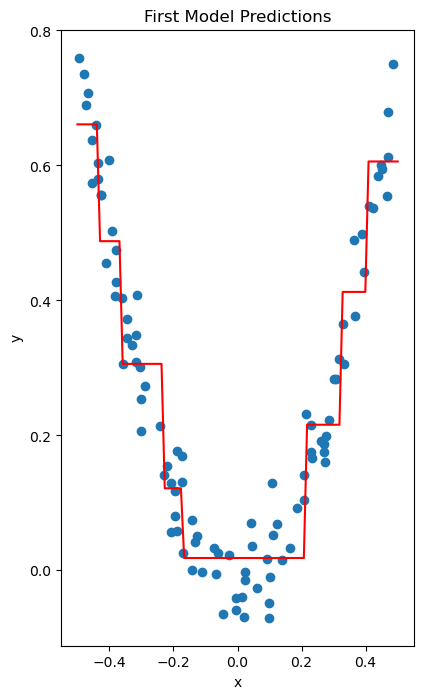

In [24]:
plt.figure(figsize=(10,8) )
plt.subplot(1,2,1)
plt.plot(x_test, y_pred1, color='red')
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('First Model Predictions')

In [25]:
# now pred2 calculate
df['pred2'] = 0.265458 + tree1.predict(df['x'].values.reshape(100,1))
df['residuals2'] = df['y'] - df['pred2']

In [26]:
df.head()

,x,y,pred1,residuals1,pred2,residuals2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022


In [27]:
#now train another model where input x and output is residuals2
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df['x'].values.reshape(100,1), df['residuals2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [28]:
#calculate pred2
y_pred2 = 0.265458 + sum(regressor.predict(x_test.reshape(-1,1)) for regressor in [tree1, tree2])

Text(0.5, 1.0, 'Second Model Predictions')

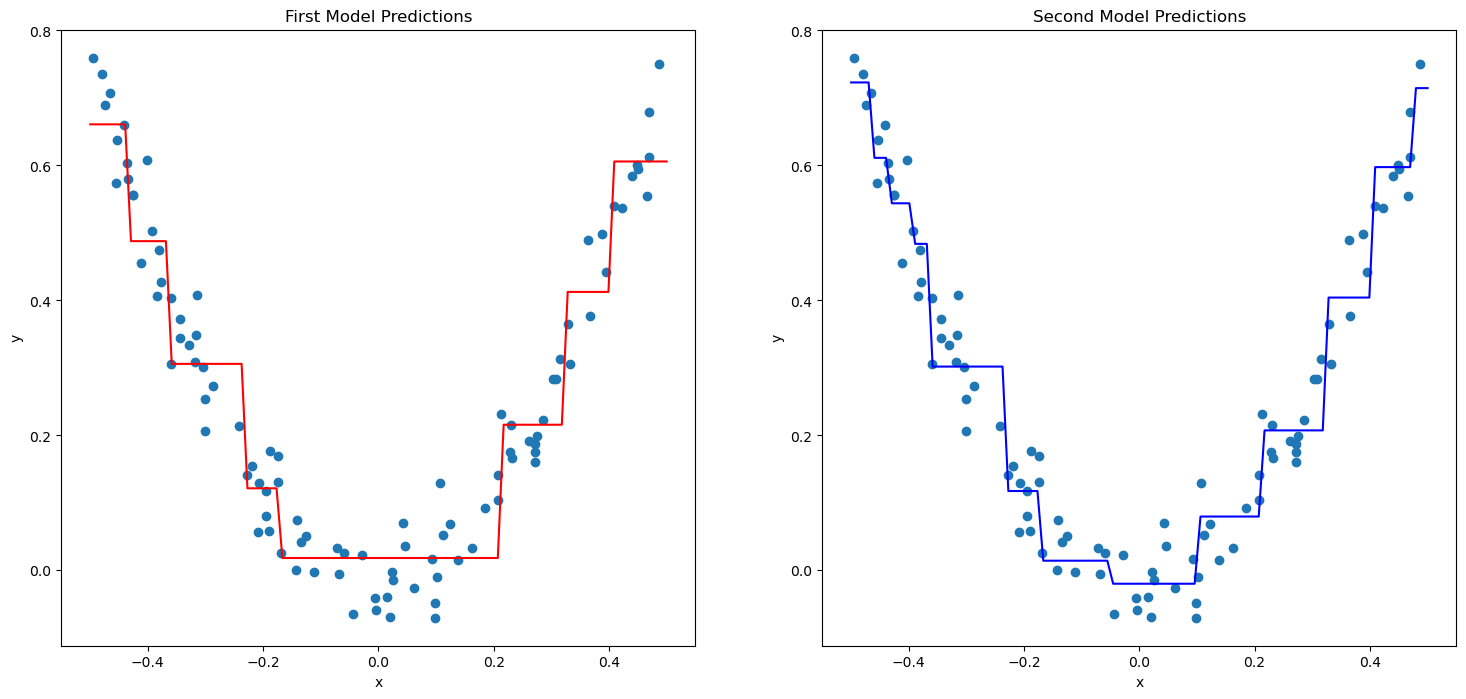

In [32]:
plt.figure(figsize=(18,8) )
plt.subplot(1,2,1)
plt.plot(x_test, y_pred1, color='red')
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('First Model Predictions')

plt.subplot(1,2,2)
plt.plot(x_test, y_pred2, color='blue')
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Second Model Predictions')